/usr/local/lib/python3.10/dist-packages/tensorflow/lite/python/util.py:55: DeprecationWarning: jax.xla_computation is deprecated. Please use the AOT APIs; see https://jax.readthedocs.io/en/latest/aot.html. For example, replace xla_computation(f)(*xs) with jit(f).lower(*xs).compiler_ir('hlo'). See CHANGELOG.md for 0.4.30 for more examples.
  from jax import xla_computation as _xla_computation
/usr/local/lib/python3.10/dist-packages/gymnasium/core.py:297: UserWarning: WARN: env.num_envs to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.num_envs` for environment variables or `env.get_attr('num_envs')` that will search the reminding wrappers.
  logger.warn(


Episode: 100,000, Total Reward: -8,843.00, Total Bet: 100,000.00, Reward/Bet Ratio: -8.84%
Episode: 200,000, Total Reward: -13,538.00, Total Bet: 200,000.00, Reward/Bet Ratio: -6.77%
Episode: 300,000, Total Reward: -18,230.00, Total Bet: 300,000.00, Reward/Bet Ratio: -6.08%
Episode: 400,000, Total Reward: -23,578.00, Total Bet: 400,000.00, Reward/Bet Ratio: -5.89%
Episode: 500,000, Total Reward: -28,256.00, Total Bet: 500,000.00, Reward/Bet Ratio: -5.65%
Episode: 600,000, Total Reward: -33,310.00, Total Bet: 600,000.00, Reward/Bet Ratio: -5.55%
Episode: 700,000, Total Reward: -38,168.00, Total Bet: 700,000.00, Reward/Bet Ratio: -5.45%
Episode: 800,000, Total Reward: -43,137.00, Total Bet: 800,000.00, Reward/Bet Ratio: -5.39%
Episode: 900,000, Total Reward: -47,699.00, Total Bet: 900,000.00, Reward/Bet Ratio: -5.30%
Episode: 1,000,000, Total Reward: -52,357.00, Total Bet: 1,000,000.00, Reward/Bet Ratio: -5.24%
Episode: 1,100,000, Total Reward: -57,775.00, Total Bet: 1,100,000.00, Reward

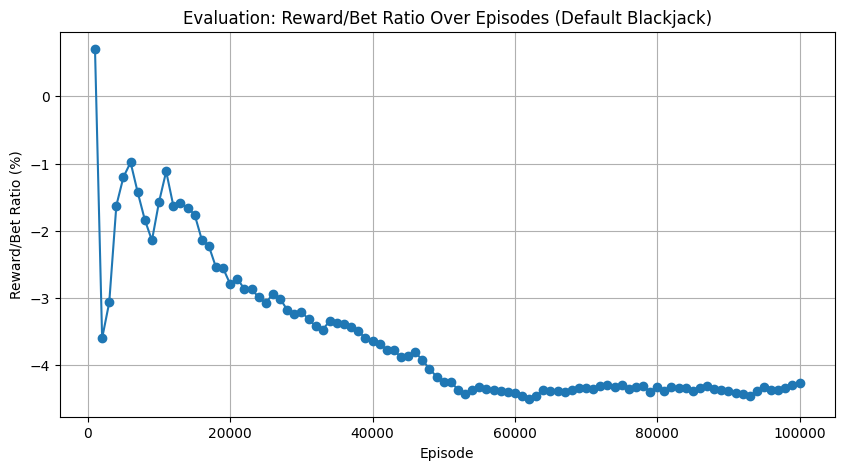

In [1]:
import math
import gymnasium as gym
from gymnasium.wrappers import RecordEpisodeStatistics, FlattenObservation
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_checker import check_env
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# Define a Cosine Learning Rate Schedule
# ----------------------------
def cosine_lr_schedule(progress_remaining):
    """
    Cosine learning rate schedule.
    progress_remaining: float in [0,1], where 1.0 is the start and 0.0 is the end.
    Decays the learning rate from 1e-4 to 1e-6 following a cosine schedule.
    """
    lr_initial = 1e-4
    lr_min = 1e-6
    cosine_decay = 0.5 * (1 + math.cos(math.pi * (1 - progress_remaining)))
    return lr_min + (lr_initial - lr_min) * cosine_decay

# ----------------------------
# Custom Wrapper to Attach Bet Info
# ----------------------------
class BetInfoWrapper(gym.Wrapper):
    """
    A gym Wrapper that records the bet placed in an episode.
    For terminal episodes, it adds a key "bet" to the info dictionary.
    In the default Blackjack environment, only HIT (0) and STK (1) are available,
    so we always set bet = 1.0.
    """
    def __init__(self, env):
        super(BetInfoWrapper, self).__init__(env)
    
    def step(self, action):
        self.last_action = action  # store last action taken (unused here)
        obs, reward, terminated, truncated, info = self.env.step(action)
        if terminated or truncated:
            info["bet"] = 1.0  # Always 1.0 in default Blackjack
        return obs, reward, terminated, truncated, info

# ----------------------------
# Custom Callback for Training Metrics
# ----------------------------
class TrainingMetricsCallback(BaseCallback):
    """
    Custom callback that logs and stores the reward-to-bet ratio every 'print_freq' episodes.
    The metric is computed as:
      (Total reward across episodes / Total bet placed across episodes) * 100.
    """
    def __init__(self, print_freq=100_000, verbose=0):
        super(TrainingMetricsCallback, self).__init__(verbose)
        self.print_freq = print_freq
        self.total_reward = 0.0
        self.total_bet = 0.0
        self.episode_count = 0
        self.episode_history = []
        self.ratio_history = []
    
    def _on_step(self) -> bool:
        infos = self.locals.get("infos", None)
        if infos is not None:
            if isinstance(infos, list):
                for info in infos:
                    if "episode" in info:
                        self.episode_count += 1
                        self.total_reward += info["episode"]["r"]
                        self.total_bet += info.get("bet", 1.0)
                        if self.episode_count % self.print_freq == 0:
                            ratio = (self.total_reward / self.total_bet * 100.0) if self.total_bet > 0 else 0.0
                            print(f"Episode: {self.episode_count:,}, Total Reward: {self.total_reward:,.2f}, "
                                  f"Total Bet: {self.total_bet:,.2f}, Reward/Bet Ratio: {ratio:,.2f}%")
                            self.episode_history.append(self.episode_count)
                            self.ratio_history.append(ratio)
            else:
                if "episode" in infos:
                    self.episode_count += 1
                    self.total_reward += infos["episode"]["r"]
                    self.total_bet += infos.get("bet", 1.0)
                    if self.episode_count % self.print_freq == 0:
                        ratio = (self.total_reward / self.total_bet * 100.0) if self.total_bet > 0 else 0.0
                        print(f"Episode: {self.episode_count:,}, Total Reward: {self.total_reward:,.2f}, "
                              f"Total Bet: {self.total_bet:,.2f}, Reward/Bet Ratio: {ratio:,.2f}%")
                        self.episode_history.append(self.episode_count)
                        self.ratio_history.append(ratio)
        return True

# ----------------------------
# Create the Default Blackjack Environment and Wrap It
# ----------------------------
# Use Gymnasium's default Blackjack-v1.
env = gym.make("Blackjack-v1")
# Flatten the observation so that the Tuple observation becomes a flat array.
env = FlattenObservation(env)
env = BetInfoWrapper(env)
env = RecordEpisodeStatistics(env)  # This records episode info into the "episode" key

# (Optional) Check that the environment follows Gymnasium's API.
check_env(env, warn=True)

# ----------------------------
# Initialize the PPO Agent
# ----------------------------
model = PPO(
    "MlpPolicy",
    env,
    gamma=1,
    learning_rate=cosine_lr_schedule,  # Use the cosine learning rate schedule.
    verbose=0,  # Suppress default PPO logs; we only print our custom metrics.
    n_steps=2048,
    batch_size=64,
    ent_coef=0.01,
)

# Create the training metrics callback instance (prints every 100,000 episodes).
metrics_callback = TrainingMetricsCallback(print_freq=100_000, verbose=0)

# ----------------------------
# Train the Model
# ----------------------------
model.learn(total_timesteps=20_000_000, callback=metrics_callback)
model.save("ppo_blackjack_default")
print("Training complete and model saved as 'ppo_blackjack_default'.")

# ----------------------------
# Evaluation
# ----------------------------
num_eval_episodes = 100_000
eval_reward_history = []
eval_bet_history = []
eval_ratio_history = []
eval_episode_nums = []

wins = 0
draws = 0
losses = 0

print("Starting evaluation on default Blackjack...")
for episode in range(1, num_eval_episodes + 1):
    obs, _ = env.reset()
    done = False
    
    while not done:
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = env.step(action)
    
    # Get the final reward and bet from info (bet is always 1.0)
    episode_reward = reward
    episode_bet = info.get("bet", 1.0)
    
    eval_reward_history.append(episode_reward)
    eval_bet_history.append(episode_bet)
    
    # Classify outcome: win if reward > 0, draw if reward == 0, loss if reward < 0.
    if episode_reward > 0:
        wins += 1
    elif episode_reward == 0:
        draws += 1
    else:
        losses += 1
    
    # Every 1,000 episodes, compute cumulative reward/ bet ratio and record it.
    if episode % 1000 == 0:
        total_reward = np.sum(eval_reward_history)
        total_bet = np.sum(eval_bet_history)
        ratio = (total_reward / total_bet * 100) if total_bet > 0 else 0.0
        eval_ratio_history.append(ratio)
        eval_episode_nums.append(episode)
        print(f"Evaluation Episode {episode:,}: Cumulative Reward/Bet Ratio = {ratio:.2f}%")

win_percent = wins / num_eval_episodes * 100
draw_percent = draws / num_eval_episodes * 100
loss_percent = losses / num_eval_episodes * 100

print("\nFinal Evaluation Results:")
print(f"Win %: {win_percent:.2f}%")
print(f"Draw %: {draw_percent:.2f}%")
print(f"Loss %: {loss_percent:.2f}%")

# Plot evaluation reward/ bet ratio over episodes.
plt.figure(figsize=(10, 5))
plt.plot(eval_episode_nums, eval_ratio_history, marker='o', linestyle='-')
plt.title("Evaluation: Reward/Bet Ratio Over Episodes (Default Blackjack)")
plt.xlabel("Episode")
plt.ylabel("Reward/Bet Ratio (%)")
plt.grid(True)
plt.show()